# 🌾 Prediksi Rekomendasi Tanaman Berdasarkan Kondisi Tanah
### Menggunakan Machine Learning: Logistic Regression, Random Forest, XGBoost
**Dataset:** Crop Recommender Dataset with Soil Nutrients (Kaggle — manikantasanjayv)  
**Tujuan:** Memprediksi tanaman yang paling sesuai berdasarkan parameter kesuburan tanah (N, P, K, pH) dan kondisi iklim  
**Referensi:** Advancing crop recommendation system with supervised ML and XAI — Scientific Reports (2025)

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, time, json, joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

print('Library berhasil diimport!')
print('Pandas :', pd.__version__)
print('Numpy  :', np.__version__)


Library berhasil diimport!
Pandas : 2.3.3
Numpy  : 2.4.6


## 2. Load Dataset

In [2]:
base_path = '/kaggle/input'
csv_files = []
for root, dirs, files in os.walk(base_path):
    for f in files:
        if f.endswith('.csv'):
            csv_files.append(os.path.join(root, f))

print('File CSV ditemukan:')
for f in csv_files:
    print(' -', f)

df = pd.read_csv(csv_files[0])
print()
print('Dataset berhasil dimuat!')
print('Shape:', df.shape[0], 'baris x', df.shape[1], 'kolom')


File CSV ditemukan:
 - /kaggle/input/datasets/manikantasanjayv/crop-recommender-dataset-with-soil-nutrients/dataset.csv

Dataset berhasil dimuat!
Shape: 620 baris x 12 kolom


## 3. Exploratory Data Analysis (EDA)

In [3]:
print('=== 5 Baris Pertama ===')
display(df.head())
print()
print('=== Info Dataset ===')
print(df.info())
print()
print('=== Statistik Deskriptif ===')
display(df.describe().round(2))


=== 5 Baris Pertama ===


,N,P,K,ph,EC,S,Cu,Fe,Mn,Zn,B,label
0,143,69,217,5.9,0.58,0.23,10.20,116.35,59.96,54.85,21.29,pomegranate
1,170,36,216,5.9,0.15,0.28,15.69,114.20,56.87,31.28,28.62,pomegranate
2,158,66,219,6.8,0.34,0.20,15.29,65.87,51.81,57.12,27.59,pomegranate
3,133,45,207,6.4,0.94,0.21,8.48,103.10,43.81,68.50,47.29,pomegranate
4,132,48,218,6.7,0.54,0.19,5.59,63.40,56.40,46.71,31.04,pomegranate



=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 620 entries, 0 to 619
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   N       620 non-null    int64  
 1   P       620 non-null    int64  
 2   K       620 non-null    int64  
 3   ph      620 non-null    float64
 4   EC      620 non-null    float64
 5   S       620 non-null    float64
 6   Cu      620 non-null    float64
 7   Fe      620 non-null    float64
 8   Mn      620 non-null    float64
 9   Zn      620 non-null    float64
 10  B       620 non-null    float64
 11  label   620 non-null    object 
dtypes: float64(8), int64(3), object(1)
memory usage: 58.3+ KB
None

=== Statistik Deskriptif ===


,N,P,K,ph,EC,S,Cu,Fe,Mn,Zn,B
count,620.00,620.00,620.00,620.00,620.00,620.00,620.00,620.00,620.00,620.00,620.00
mean,135.70,52.51,161.40,6.11,0.89,0.48,17.32,117.21,219.91,34.34,28.75
std,31.81,24.67,81.29,0.69,0.64,5.78,6.44,62.78,342.00,11.54,19.64
min,30.00,10.00,51.00,4.50,0.01,0.01,0.18,3.81,20.58,17.99,1.02
25%,116.00,30.00,89.00,5.70,0.30,0.09,12.59,68.31,58.78,24.73,13.44
50%,138.00,54.00,157.50,6.10,0.78,0.17,16.91,108.24,73.58,31.42,23.22
75%,160.00,75.00,206.00,6.50,1.39,0.24,21.10,155.62,163.67,43.54,42.77
max,198.00,100.00,369.00,8.00,2.48,113.20,35.00,276.72,1572.54,70.00,74.56


In [4]:
print('=== Missing Values ===')
missing = df.isnull().sum()
if missing.sum() == 0:
    print('Tidak ada missing values.')
else:
    print(missing[missing > 0])
print()
print('Duplikat:', df.duplicated().sum(), 'baris')
print()
# Deteksi kolom target otomatis
TARGET_COL = 'label'
for col in df.columns:
    if col.lower() in ['label', 'crop', 'target', 'class']:
        TARGET_COL = col
        break
print('Kolom target terdeteksi:', TARGET_COL)
print()
print('=== Distribusi Kelas (' + TARGET_COL + ') ===')
print(df[TARGET_COL].value_counts())
print()
print('Jumlah kelas unik:', df[TARGET_COL].nunique())


=== Missing Values ===
Tidak ada missing values.

Duplikat: 0 baris

Kolom target terdeteksi: label

=== Distribusi Kelas (label) ===
label
pomegranate    104
mango          104
grapes         104
mulberry       104
ragi           104
potato         100
Name: count, dtype: int64

Jumlah kelas unik: 6


## 4. Visualisasi EDA

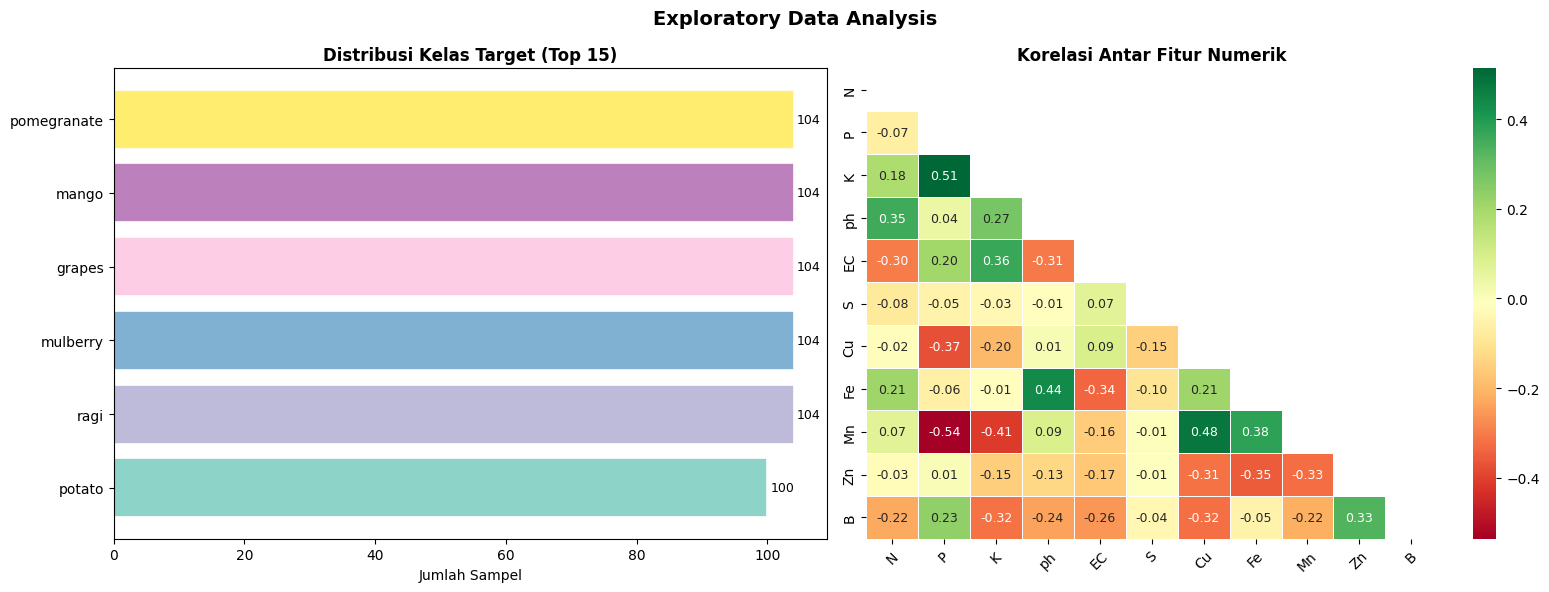

Visualisasi EDA selesai


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Exploratory Data Analysis', fontsize=14, fontweight='bold')

# Plot 1: Top 15 tanaman terbanyak
val_counts = df[TARGET_COL].value_counts().head(15)
colors = plt.cm.Set3(np.linspace(0, 1, len(val_counts)))
axes[0].barh(val_counts.index[::-1], val_counts.values[::-1],
             color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Distribusi Kelas Target (Top 15)', fontweight='bold')
axes[0].set_xlabel('Jumlah Sampel')
for i, v in enumerate(val_counts.values[::-1]):
    axes[0].text(v + 0.5, i, str(v), va='center', fontsize=9)

# Plot 2: Korelasi fitur numerik
num_df = df.select_dtypes(include=np.number)
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=axes[1], cmap='RdYlGn',
            annot=True, fmt='.2f', linewidths=0.5, annot_kws={'size': 9})
axes[1].set_title('Korelasi Antar Fitur Numerik', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi EDA selesai')


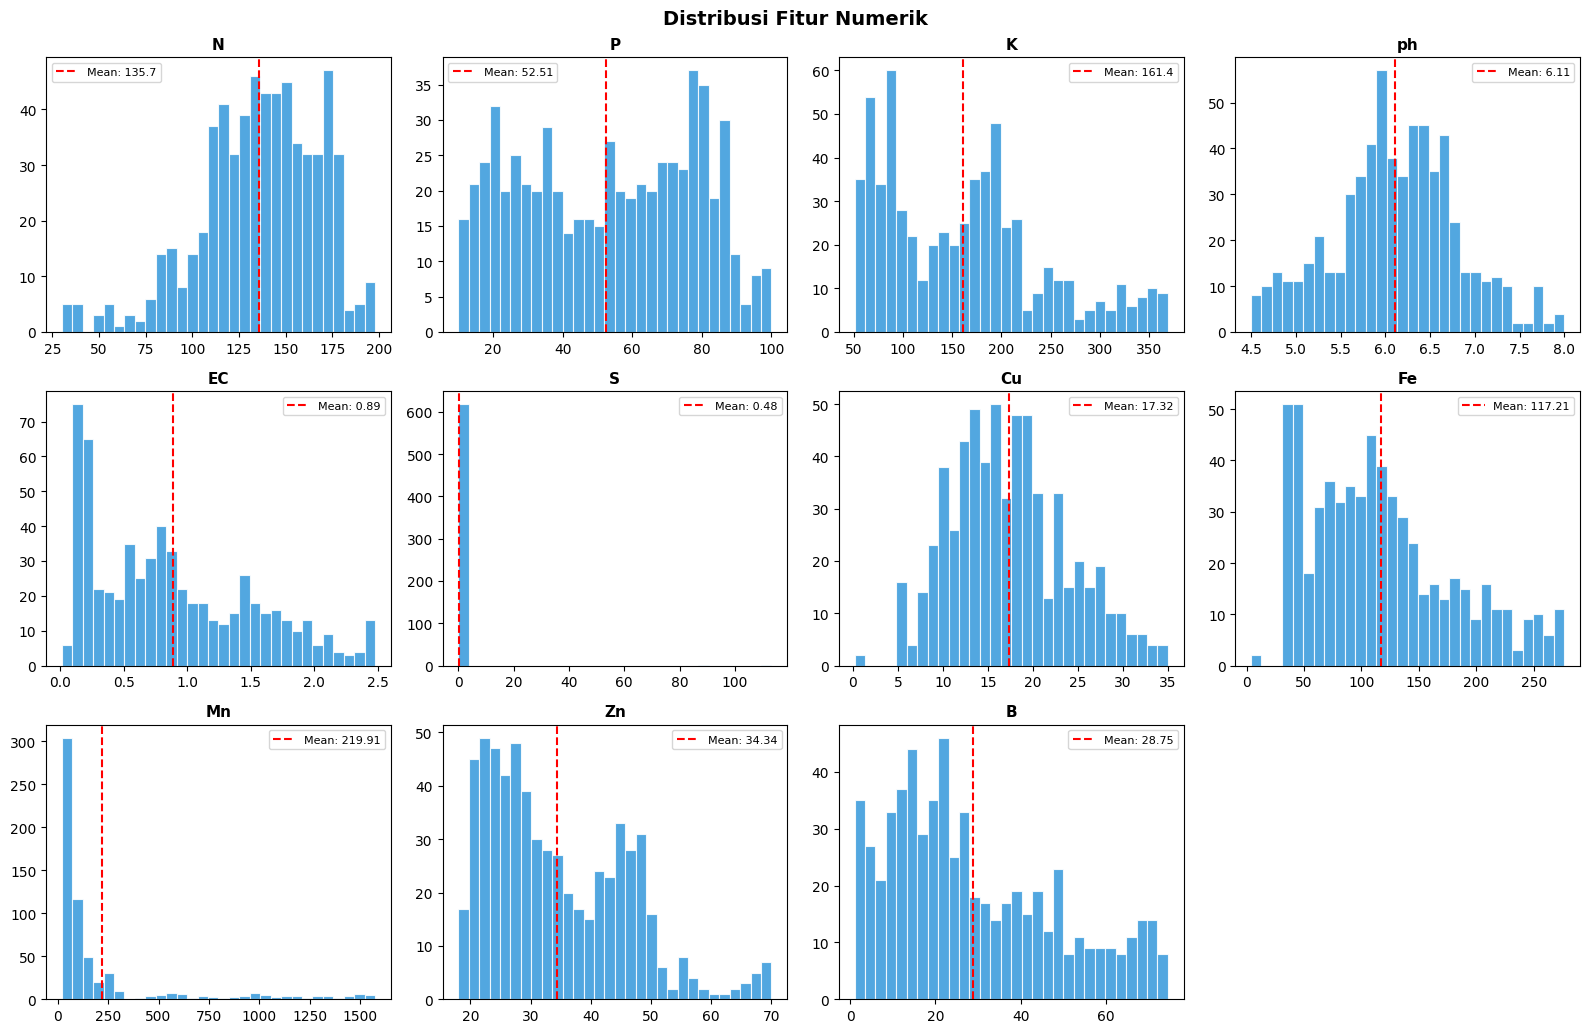

In [6]:
# Distribusi fitur numerik
num_cols = df.select_dtypes(include=np.number).columns.tolist()
n_plot = len(num_cols)
n_rows = (n_plot + 3) // 4

fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='#3498db',
                 edgecolor='white', linewidth=0.8, alpha=0.85)
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--',
                    linewidth=1.5, label='Mean: ' + str(round(df[col].mean(), 2)))
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('distribusi_fitur.png', dpi=150, bbox_inches='tight')
plt.show()


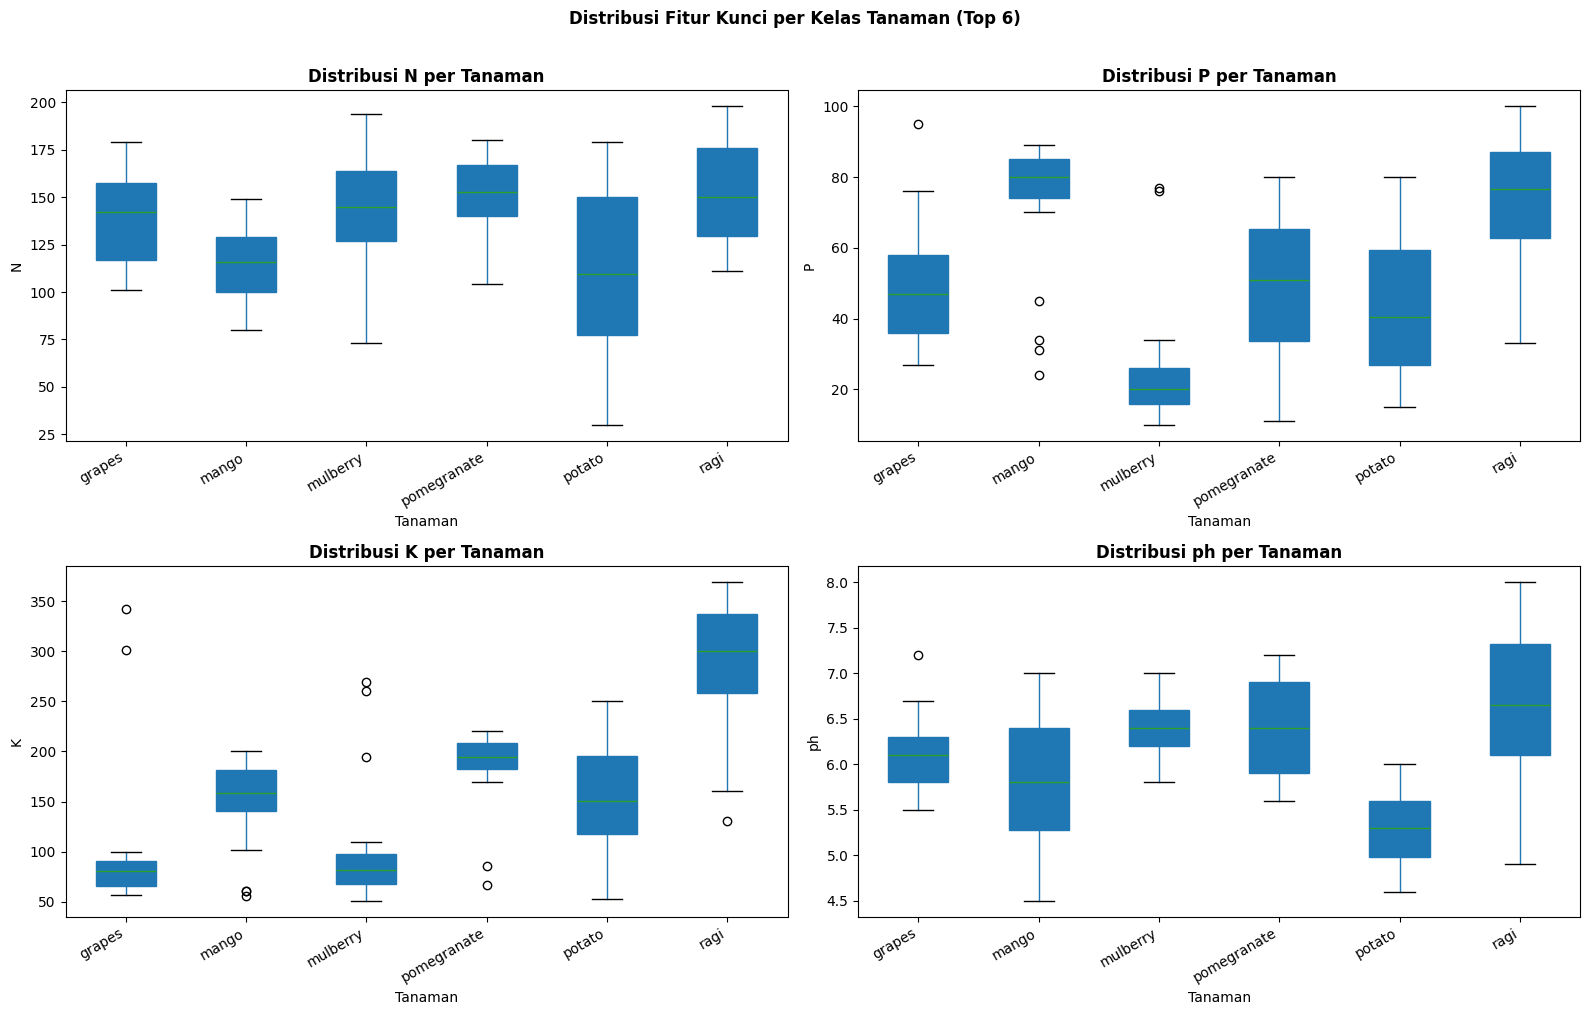

In [7]:
# Boxplot fitur per kelas (ambil top 6 kelas)
top_labels = df[TARGET_COL].value_counts().head(6).index.tolist()
df_top = df[df[TARGET_COL].isin(top_labels)]

key_features = ['N', 'P', 'K', 'ph'] if 'N' in df.columns else num_cols[:4]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    df_top.boxplot(column=feat, by=TARGET_COL, ax=axes[i],
                   grid=False, patch_artist=True)
    axes[i].set_title('Distribusi ' + feat + ' per Tanaman', fontweight='bold')
    axes[i].set_xlabel('Tanaman')
    axes[i].set_ylabel(feat)
    plt.sca(axes[i])
    plt.xticks(rotation=30, ha='right')

plt.suptitle('Distribusi Fitur Kunci per Kelas Tanaman (Top 6)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('boxplot_fitur.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Preprocessing

In [8]:
df_clean = df.copy()

# 1. Hapus duplikat
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print('Duplikat dihapus:', before - len(df_clean), 'baris')

# 2. Pisahkan fitur dan target
X = df_clean.drop(columns=[TARGET_COL])
y = df_clean[TARGET_COL]

# 3. Encode kolom kategorikal pada fitur (jika ada)
label_encoders = {}
cat_cols = X.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    le_col = LabelEncoder()
    X[col] = le_col.fit_transform(X[col].astype(str))
    label_encoders[col] = le_col
    print('Encoded fitur:', col)

# 4. Encode target
le_target = LabelEncoder()
y = le_target.fit_transform(y.astype(str))
label_encoders[TARGET_COL] = le_target
print('Kelas target (' + str(len(le_target.classes_)) + ' kelas):', list(le_target.classes_))

# 5. Imputasi missing value
imputer = SimpleImputer(strategy='median')
X_arr = imputer.fit_transform(X)
X = pd.DataFrame(X_arr, columns=X.columns)

print()
print('Fitur yang dipakai:', list(X.columns))
print('Jumlah fitur :', X.shape[1])
print('Jumlah sampel:', X.shape[0])
print('Jumlah kelas :', len(np.unique(y)))


Duplikat dihapus: 0 baris
Kelas target (6 kelas): ['grapes', 'mango', 'mulberry', 'pomegranate', 'potato', 'ragi']

Fitur yang dipakai: ['N', 'P', 'K', 'ph', 'EC', 'S', 'Cu', 'Fe', 'Mn', 'Zn', 'B']
Jumlah fitur : 11
Jumlah sampel: 620
Jumlah kelas : 6


## 6. Cek Imbalance & SMOTE

In [9]:
from collections import Counter

counter = Counter(y)
min_class = min(counter.values())
max_class = max(counter.values())
imbalance_ratio = min_class / max_class

print('Distribusi kelas (5 terkecil):')
for k, v in sorted(counter.items(), key=lambda x: x[1])[:5]:
    pct = round(v / len(y) * 100, 1)
    print('  ' + str(le_target.classes_[k]) + ': ' + str(v) + ' sampel (' + str(pct) + '%)')

print()
print('Rasio imbalance (min/max):', round(imbalance_ratio, 3))

USE_SMOTE = False
if imbalance_ratio < 0.5:
    print('Dataset tidak seimbang, menerapkan SMOTE...')
    k_val = min(5, min_class - 1)
    sm = SMOTE(random_state=42, k_neighbors=k_val)
    X, y = sm.fit_resample(X, y)
    USE_SMOTE = True
    print('SMOTE selesai. Total sampel sekarang:', len(y))
else:
    print('Dataset cukup seimbang, SMOTE tidak diterapkan')


Distribusi kelas (5 terkecil):
  potato: 100 sampel (16.1%)
  pomegranate: 104 sampel (16.8%)
  mango: 104 sampel (16.8%)
  grapes: 104 sampel (16.8%)
  mulberry: 104 sampel (16.8%)

Rasio imbalance (min/max): 0.962
Dataset cukup seimbang, SMOTE tidak diterapkan


## 7. Split Data Train & Test

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Data berhasil dibagi:')
print('  Training :', X_train.shape[0], 'sampel (80%)')
print('  Testing  :', X_test.shape[0], 'sampel (20%)')


Data berhasil dibagi:
  Training : 496 sampel (80%)
  Testing  : 124 sampel (20%)


## 8. Definisi 3 Model

In [11]:
n_classes     = len(np.unique(y))
is_multiclass = n_classes > 2

models = {}

models['Logistic Regression'] = {
    'model': LogisticRegression(
        max_iter=2000,
        random_state=42,
        C=1.0,
        multi_class='multinomial'
    ),
    'scaled': True
}

models['Random Forest'] = {
    'model': RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
    'scaled': False
}

models['XGBoost'] = {
    'model': XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    ),
    'scaled': False
}

print('3 model siap dilatih:')
for name in models:
    print('  -', name)
print('Jumlah kelas:', n_classes)


3 model siap dilatih:
  - Logistic Regression
  - Random Forest
  - XGBoost
Jumlah kelas: 6


## 9. Training & Evaluasi

In [12]:
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

col1 = 'Model'
col2 = 'CV Acc'
col3 = 'Test Acc'
col4 = 'F1-Macro'
col5 = 'Waktu'
print('='*65)
print(f'{col1:<22} {col2:<14} {col3:<11} {col4:<11} {col5:>6}')
print('='*65)

for name, config in models.items():
    model      = config['model']
    use_scaled = config['scaled']
    X_tr = X_train_scaled if use_scaled else X_train
    X_te = X_test_scaled  if use_scaled else X_test
    start = time.time()
    cv_scores = cross_val_score(
        model,
        X_train_scaled if use_scaled else X_train,
        y_train, cv=cv, scoring='accuracy', n_jobs=-1
    )
    model.fit(X_tr, y_train)
    y_pred  = model.predict(X_te)
    elapsed = time.time() - start
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro', zero_division=0)
    results[name] = {
        'model'   : model,
        'scaled'  : use_scaled,
        'cv_mean' : cv_scores.mean(),
        'cv_std'  : cv_scores.std(),
        'test_acc': acc,
        'f1_macro': f1,
        'y_pred'  : y_pred,
        'time'    : elapsed
    }
    cv_str = str(round(cv_scores.mean(), 4)) + '+-' + str(round(cv_scores.std(), 3))
    print(f'{name:<22} {cv_str:<14} {acc:>9.4f}  {f1:>10.4f}  {elapsed:>5.1f}s')

print('='*65)
best_name   = max(results, key=lambda x: results[x]['test_acc'])
best_result = results[best_name]
print()
print('Model Terbaik : ' + best_name)
print('Test Accuracy : ' + str(round(best_result['test_acc'], 4)))
print('F1-Macro      : ' + str(round(best_result['f1_macro'], 4)))
print('CV Accuracy   : ' + str(round(best_result['cv_mean'], 4)) + ' +- ' + str(round(best_result['cv_std'], 4)))


Model                  CV Acc         Test Acc    F1-Macro     Waktu


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

Logistic Regression    0.9658+-0.03      0.9597      0.9603    2.8s
Random Forest          0.9698+-0.022     0.9597      0.9603    2.1s
XGBoost                0.9618+-0.018     0.9597      0.9603    1.3s

Model Terbaik : Logistic Regression
Test Accuracy : 0.9597
F1-Macro      : 0.9603
CV Accuracy   : 0.9658 +- 0.0295


## 10. Visualisasi Perbandingan Model

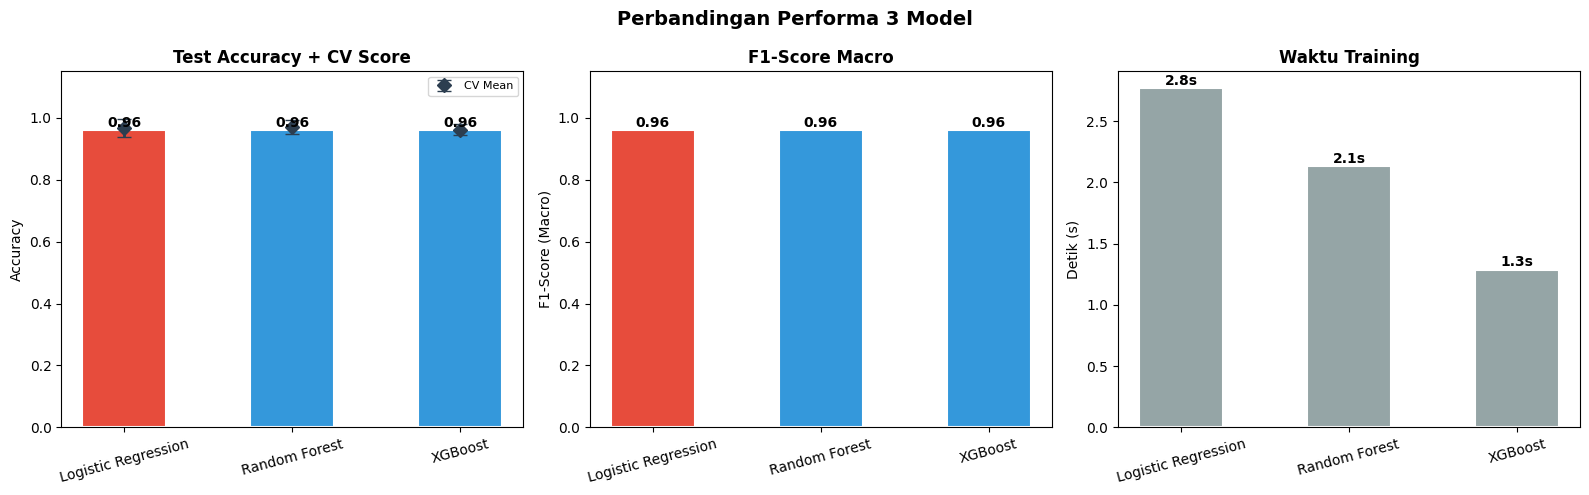

Grafik perbandingan disimpan


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Perbandingan Performa 3 Model', fontsize=14, fontweight='bold')

model_names = list(results.keys())
test_accs   = [results[m]['test_acc'] for m in model_names]
cv_means    = [results[m]['cv_mean']  for m in model_names]
cv_stds     = [results[m]['cv_std']   for m in model_names]
f1_macros   = [results[m]['f1_macro'] for m in model_names]
times       = [results[m]['time']     for m in model_names]
palette     = ['#e74c3c' if m == best_name else '#3498db' for m in model_names]

bars = axes[0].bar(model_names, test_accs, color=palette,
                   edgecolor='white', linewidth=1.5, width=0.5)
axes[0].errorbar(range(len(model_names)), cv_means, yerr=cv_stds,
                 fmt='D', color='#2c3e50', markersize=7,
                 capsize=5, linewidth=2, label='CV Mean')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Test Accuracy + CV Score', fontweight='bold')
axes[0].set_ylim(0, 1.15)
axes[0].legend(fontsize=8)
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, test_accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 str(round(val, 3)), ha='center', fontweight='bold', fontsize=10)

bars2 = axes[1].bar(model_names, f1_macros, color=palette,
                    edgecolor='white', linewidth=1.5, width=0.5)
axes[1].set_ylabel('F1-Score (Macro)')
axes[1].set_title('F1-Score Macro', fontweight='bold')
axes[1].set_ylim(0, 1.15)
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, f1_macros):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 str(round(val, 3)), ha='center', fontweight='bold', fontsize=10)

bars3 = axes[2].bar(model_names, times, color='#95a5a6',
                    edgecolor='white', linewidth=1.5, width=0.5)
axes[2].set_ylabel('Detik (s)')
axes[2].set_title('Waktu Training', fontweight='bold')
axes[2].tick_params(axis='x', rotation=15)
for bar, val in zip(bars3, times):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + max(times)*0.01,
                 str(round(val, 1)) + 's', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('perbandingan_model.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik perbandingan disimpan')


## 11. Confusion Matrix Model Terbaik

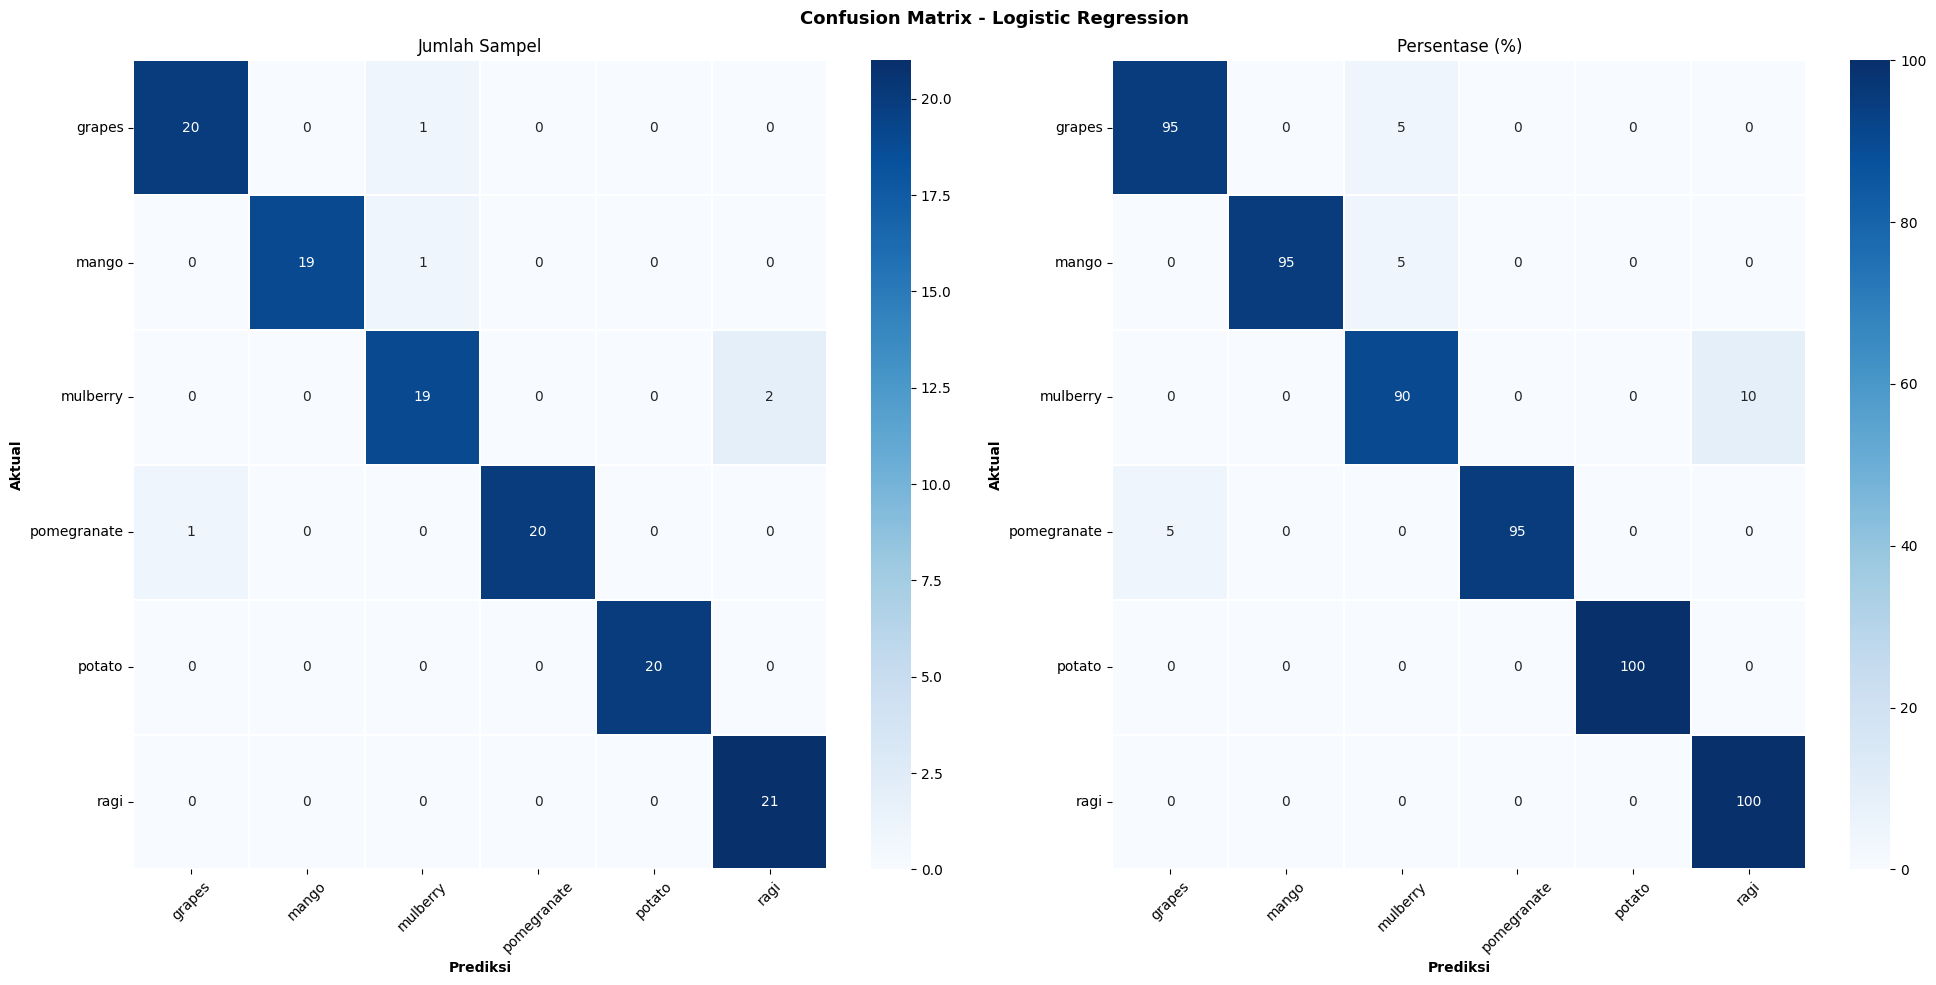


=== Classification Report ===
              precision    recall  f1-score   support

      grapes       0.95      0.95      0.95        21
       mango       1.00      0.95      0.97        20
    mulberry       0.90      0.90      0.90        21
 pomegranate       1.00      0.95      0.98        21
      potato       1.00      1.00      1.00        20
        ragi       0.91      1.00      0.95        21

    accuracy                           0.96       124
   macro avg       0.96      0.96      0.96       124
weighted avg       0.96      0.96      0.96       124



In [14]:
best_model  = best_result['model']
y_pred_best = best_result['y_pred']
class_names = le_target.classes_.astype(str)

cm     = confusion_matrix(y_test, y_pred_best)
cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100

# Ukuran figure menyesuaikan jumlah kelas
fig_size = max(10, len(class_names) * 0.6)
fig, axes = plt.subplots(1, 2, figsize=(fig_size * 2, fig_size))
fig.suptitle('Confusion Matrix - ' + best_name, fontsize=13, fontweight='bold')

sns.heatmap(cm, annot=len(class_names) <= 15, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.3, linecolor='white')
axes[0].set_xlabel('Prediksi', fontweight='bold')
axes[0].set_ylabel('Aktual', fontweight='bold')
axes[0].set_title('Jumlah Sampel')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

sns.heatmap(cm_pct, annot=len(class_names) <= 15, fmt='.0f', cmap='Blues', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.3, linecolor='white')
axes[1].set_xlabel('Prediksi', fontweight='bold')
axes[1].set_ylabel('Aktual', fontweight='bold')
axes[1].set_title('Persentase (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('=== Classification Report ===')
print(classification_report(y_test, y_pred_best,
                             target_names=class_names, zero_division=0))


## 12. Feature Importance

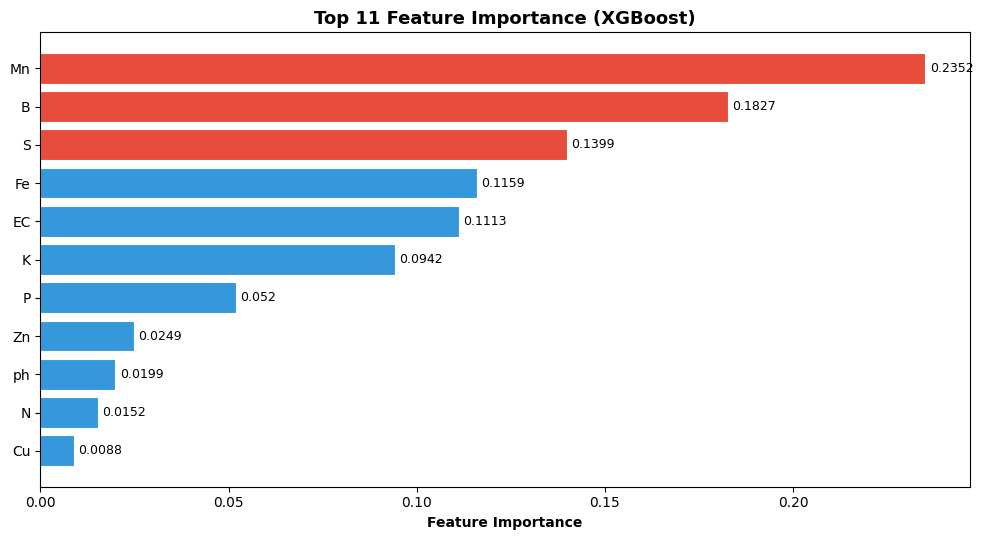

=== Fitur Terpenting (XGBoost) ===
  Mn : 0.2352
  B : 0.1827
  S : 0.1399
  Fe : 0.1159
  EC : 0.1113
  K : 0.0942
  P : 0.052
  Zn : 0.0249
  ph : 0.0199
  N : 0.0152


In [15]:
fi_name  = 'XGBoost' if 'XGBoost' in results else 'Random Forest'
fi_model = results[fi_name]['model']

importances = fi_model.feature_importances_
feat_names  = list(X.columns)

fi_df = pd.DataFrame({'Fitur': feat_names, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=True)

top_n  = min(15, len(fi_df))
fi_top = fi_df.tail(top_n)

fig, ax = plt.subplots(figsize=(10, max(5, top_n * 0.5)))
colors = ['#e74c3c' if i >= top_n - 3 else '#3498db' for i in range(top_n)]
bars = ax.barh(fi_top['Fitur'], fi_top['Importance'],
               color=colors, edgecolor='white', linewidth=0.8)
ax.set_xlabel('Feature Importance', fontweight='bold')
ax.set_title('Top ' + str(top_n) + ' Feature Importance (' + fi_name + ')',
             fontsize=13, fontweight='bold')
for bar, val in zip(bars, fi_top['Importance']):
    ax.text(val + max(importances)*0.005,
            bar.get_y() + bar.get_height()/2,
            str(round(val, 4)), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== Fitur Terpenting (' + fi_name + ') ===')
for _, row in fi_df.tail(10).iloc[::-1].iterrows():
    print('  ' + str(row['Fitur']) + ' : ' + str(round(row['Importance'], 4)))


## 13. Simpan Model

In [16]:
os.makedirs('/kaggle/working/model', exist_ok=True)

joblib.dump(best_model,     '/kaggle/working/model/best_model.pkl')
joblib.dump(scaler,         '/kaggle/working/model/scaler.pkl')
joblib.dump(imputer,        '/kaggle/working/model/imputer.pkl')
joblib.dump(label_encoders, '/kaggle/working/model/label_encoders.pkl')

for name, res in results.items():
    safe = name.lower().replace(' ', '_')
    joblib.dump(res['model'], '/kaggle/working/model/' + safe + '.pkl')

metadata = {
    'best_model_name'  : best_name,
    'target_column'    : TARGET_COL,
    'feature_columns'  : list(X.columns),
    'n_classes'        : int(n_classes),
    'class_names'      : list(le_target.classes_.astype(str)),
    'test_accuracy'    : round(float(best_result['test_acc']), 4),
    'f1_macro'         : round(float(best_result['f1_macro']), 4),
    'cv_accuracy'      : round(float(best_result['cv_mean']), 4),
    'cv_std'           : round(float(best_result['cv_std']), 4),
    'use_smote'        : USE_SMOTE,
    'best_model_scaled': bool(best_result['scaled']),
    'all_results': {
        m: {
            'test_acc': round(float(r['test_acc']), 4),
            'f1_macro': round(float(r['f1_macro']), 4),
            'cv_mean' : round(float(r['cv_mean']),  4),
            'cv_std'  : round(float(r['cv_std']),   4)
        } for m, r in results.items()
    }
}

with open('/kaggle/working/model/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Model berhasil disimpan!')
print('  best_model.pkl, scaler.pkl, imputer.pkl, metadata.json')


Model berhasil disimpan!
  best_model.pkl, scaler.pkl, imputer.pkl, metadata.json


## 14. Ringkasan Hasil

In [17]:
print('='*62)
print('          RINGKASAN HASIL PENELITIAN')
print('='*62)
print('Dataset         : ' + csv_files[0].split('/')[-1])
print('Jumlah Sampel   : ' + str(len(df)) + ' baris')
print('Jumlah Fitur    : ' + str(X.shape[1]))
print('Jumlah Kelas    : ' + str(n_classes) + ' tanaman')
print('SMOTE diterapkan: ' + ('Ya' if USE_SMOTE else 'Tidak'))
print()
col1 = 'Model'
col2 = 'CV Acc'
col3 = 'Test Acc'
col4 = 'F1-Macro'
print(f'{col1:<22} {col2:<16} {col3:<11} {col4}')
print('-'*60)
for name, res in sorted(results.items(), key=lambda x: -x[1]['test_acc']):
    marker = ' <- TERBAIK' if name == best_name else ''
    cv_str = str(round(res['cv_mean'], 4)) + '+-' + str(round(res['cv_std'], 3))
    acc_s  = str(round(res['test_acc'], 4))
    f1_s   = str(round(res['f1_macro'], 4))
    print(f'{name:<22} {cv_str:<16} {acc_s:>8}  {f1_s:>8}{marker}')
print('='*62)
print()
print('Model Terpilih : ' + best_name)
print('Test Accuracy  : ' + str(round(best_result['test_acc'], 4)))
print('F1-Score Macro : ' + str(round(best_result['f1_macro'], 4)))
print('CV Accuracy    : ' + str(round(best_result['cv_mean'], 4)) + ' +- ' + str(round(best_result['cv_std'], 4)))
print()
print('Siap untuk di-deploy ke Streamlit!')


          RINGKASAN HASIL PENELITIAN
Dataset         : dataset.csv
Jumlah Sampel   : 620 baris
Jumlah Fitur    : 11
Jumlah Kelas    : 6 tanaman
SMOTE diterapkan: Tidak

Model                  CV Acc           Test Acc    F1-Macro
------------------------------------------------------------
Logistic Regression    0.9658+-0.03       0.9597    0.9603 <- TERBAIK
Random Forest          0.9698+-0.022      0.9597    0.9603
XGBoost                0.9618+-0.018      0.9597    0.9603

Model Terpilih : Logistic Regression
Test Accuracy  : 0.9597
F1-Score Macro : 0.9603
CV Accuracy    : 0.9658 +- 0.0295

Siap untuk di-deploy ke Streamlit!


## 15. Generate app.py Streamlit

In [18]:
app_lines = [
    'import streamlit as st\n',
    'import numpy as np\n',
    'import pandas as pd\n',
    'import joblib, json\n',
    '\n',
    'st.set_page_config(\n',
    '    page_title="Rekomendasi Tanaman",\n',
    '    page_icon="🌾",\n',
    '    layout="wide"\n',
    ')\n',
    '\n',
    '@st.cache_resource\n',
    'def load_artifacts():\n',
    '    model   = joblib.load("model/best_model.pkl")\n',
    '    scaler  = joblib.load("model/scaler.pkl")\n',
    '    imputer = joblib.load("model/imputer.pkl")\n',
    '    with open("model/metadata.json") as f:\n',
    '        meta = json.load(f)\n',
    '    return model, scaler, imputer, meta\n',
    '\n',
    'model, scaler, imputer, meta = load_artifacts()\n',
    '\n',
    'st.title("🌾 Prediksi Rekomendasi Tanaman")\n',
    'st.markdown("Sistem rekomendasi tanaman berbasis **Machine Learning** berdasarkan kondisi kesuburan tanah dan iklim.")\n',
    'st.divider()\n',
    '\n',
    'with st.sidebar:\n',
    '    st.header("Informasi Model")\n',
    '    st.metric("Model Terbaik",  meta["best_model_name"])\n',
    '    st.metric("Test Accuracy",  str(round(meta["test_accuracy"]*100, 2)) + "%")\n',
    '    st.metric("F1-Score Macro", str(round(meta["f1_macro"]*100, 2)) + "%")\n',
    '    st.metric("Jumlah Kelas",   str(meta["n_classes"]) + " tanaman")\n',
    '    st.divider()\n',
    '    st.caption("Dataset: Crop Recommender - Kaggle")\n',
    '\n',
    'tab1, tab2 = st.tabs(["Prediksi Manual", "Prediksi Upload CSV"])\n',
    '\n',
    'with tab1:\n',
    '    st.subheader("Masukkan Parameter Tanah & Iklim")\n',
    '    feature_cols = meta["feature_columns"]\n',
    '    cols = st.columns(3)\n',
    '    input_vals = {}\n',
    '    for i, feat in enumerate(feature_cols):\n',
    '        with cols[i % 3]:\n',
    '            input_vals[feat] = st.number_input(feat, value=0.0, format="%.4f", key=feat)\n',
    '    st.divider()\n',
    '    if st.button("Prediksi Tanaman", type="primary", use_container_width=True):\n',
    '        input_df    = pd.DataFrame([input_vals])\n',
    '        input_imp   = imputer.transform(input_df)\n',
    '        input_final = scaler.transform(input_imp) if meta["best_model_scaled"] else input_imp\n',
    '        pred        = model.predict(input_final)[0]\n',
    '        proba       = model.predict_proba(input_final)[0]\n',
    '        class_names = meta["class_names"]\n',
    '        pred_label  = class_names[int(pred)]\n',
    '        confidence  = float(np.max(proba)) * 100\n',
    '        st.success("Tanaman yang direkomendasikan: **" + pred_label.upper() + "**")\n',
    '        st.info("Confidence: " + str(round(confidence, 1)) + "%")\n',
    '        st.markdown("**Probabilitas Top 5 Tanaman:**")\n',
    '        top5_idx   = np.argsort(proba)[::-1][:5]\n',
    '        top5_crops = [class_names[i] for i in top5_idx]\n',
    '        top5_proba = [proba[i] for i in top5_idx]\n',
    '        prob_df    = pd.DataFrame({"Tanaman": top5_crops, "Probabilitas": top5_proba})\n',
    '        st.bar_chart(prob_df.set_index("Tanaman"))\n',
    '\n',
    'with tab2:\n',
    '    st.subheader("Upload File CSV")\n',
    '    st.info("Kolom yang dibutuhkan: " + str(meta["feature_columns"]))\n',
    '    uploaded = st.file_uploader("Upload CSV", type=["csv"])\n',
    '    if uploaded:\n',
    '        df_up = pd.read_csv(uploaded)\n',
    '        st.dataframe(df_up.head())\n',
    '        if st.button("Prediksi Semua Baris", type="primary"):\n',
    '            feat_cols   = [c for c in meta["feature_columns"] if c in df_up.columns]\n',
    '            X_up        = df_up[feat_cols]\n',
    '            X_imp       = imputer.transform(X_up)\n',
    '            X_final     = scaler.transform(X_imp) if meta["best_model_scaled"] else X_imp\n',
    '            preds       = model.predict(X_final)\n',
    '            probas      = model.predict_proba(X_final)\n',
    '            class_names = meta["class_names"]\n',
    '            df_up["Rekomendasi"]  = [class_names[int(p)] for p in preds]\n',
    '            df_up["Confidence"]  = [str(round(float(np.max(pr))*100,1))+"%" for pr in probas]\n',
    '            st.success("Prediksi selesai untuk " + str(len(df_up)) + " baris")\n',
    '            st.dataframe(df_up)\n',
    '            st.download_button("Download Hasil", df_up.to_csv(index=False), "hasil_rekomendasi.csv", "text/csv")\n',
]

with open('/kaggle/working/app.py', 'w') as f:
    f.writelines(app_lines)

requirements = (
    'streamlit>=1.32.0\n'
    'pandas>=1.5.0\n'
    'numpy>=1.23.0\n'
    'scikit-learn>=1.3.0\n'
    'xgboost>=1.7.0\n'
    'imbalanced-learn>=0.11.0\n'
    'joblib>=1.2.0\n'
    'matplotlib>=3.7.0\n'
    'seaborn>=0.12.0\n'
)

with open('/kaggle/working/requirements.txt', 'w') as f:
    f.write(requirements)

print('app.py dan requirements.txt berhasil dibuat!')
print()
print('LANGKAH DEPLOY:')
print('1. Download /kaggle/working/app.py')
print('2. Download /kaggle/working/requirements.txt')
print('3. Download folder /kaggle/working/model/')
print('4. Push semua ke GitHub')
print('5. Deploy di streamlit.io/cloud')


app.py dan requirements.txt berhasil dibuat!

LANGKAH DEPLOY:
1. Download /kaggle/working/app.py
2. Download /kaggle/working/requirements.txt
3. Download folder /kaggle/working/model/
4. Push semua ke GitHub
5. Deploy di streamlit.io/cloud


In [19]:
import sklearn, xgboost, joblib, numpy, pandas
print("sklearn :", sklearn.__version__)
print("xgboost :", xgboost.__version__)
print("joblib  :", joblib.__version__)
print("numpy   :", numpy.__version__)
print("pandas  :", pandas.__version__)

sklearn : 1.6.1
xgboost : 3.2.0
joblib  : 1.5.3
numpy   : 2.4.6
pandas  : 2.3.3


In [20]:
import joblib, json, os

# Load metadata lama
with open('/kaggle/working/model/metadata.json') as f:
    meta = json.load(f)

# Simpan ulang model dan scaler (tanpa imputer)
# Ini sudah ada, tinggal update metadata
meta['use_imputer'] = False
with open('/kaggle/working/model/metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('metadata.json diupdate')
print('Download ulang metadata.json dari /kaggle/working/model/')

metadata.json diupdate
Download ulang metadata.json dari /kaggle/working/model/
